In [7]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.set_theme(context='talk',
                  style='ticks',
                  palette='colorblind',
                  rc={'axes.linewidth':1.2,"grid.alpha":0.3,"grid.linestyle":'--'})
import cartopy.crs as ccrs
import numpy as np
import pandas as pd
import json
from scipy.interpolate import griddata
from matplotlib.gridspec import GridSpec
from tqdm import tqdm 
import cartopy.feature as cfeature
from geostat_isoscapes_tools import sisal_utils,geostat_utils,plot_utils,utils
from scipy.stats import pearsonr
from scipy import odr
import rasterio
from rasterio.transform import xy

### Fig. 1

In [2]:
sisal_df = sisal_utils.get_basic_cleaned_merged_sisal_data()

itrace_df = geostat_utils.get_preprocessed_itrace_data(
    data_folder='/media/luluxette/T7_Shield/pdm/iTrace/',
    true_kyr=20,
    sim_prefix = 'b.e13.Bi1850C5.f19_g16',
    sim_suffix ='100001-199912', #12:'800001-899912', #16:'400001-499912', #20 :'100001-199912',
    sim_forcings='ice_ghg_orb_wtr',
    sim_kyr= 20,
    sim_num='01',
    sim_model='clm2.h0',
    res=200,
    buffer_km=0,
    format = 'df',
    amount_weighted=False,
    verbose=True
    )


-> loading SISAL database
   cleaning samples
loading and cleaning done.
loading itrace files
   bins of width=200 years


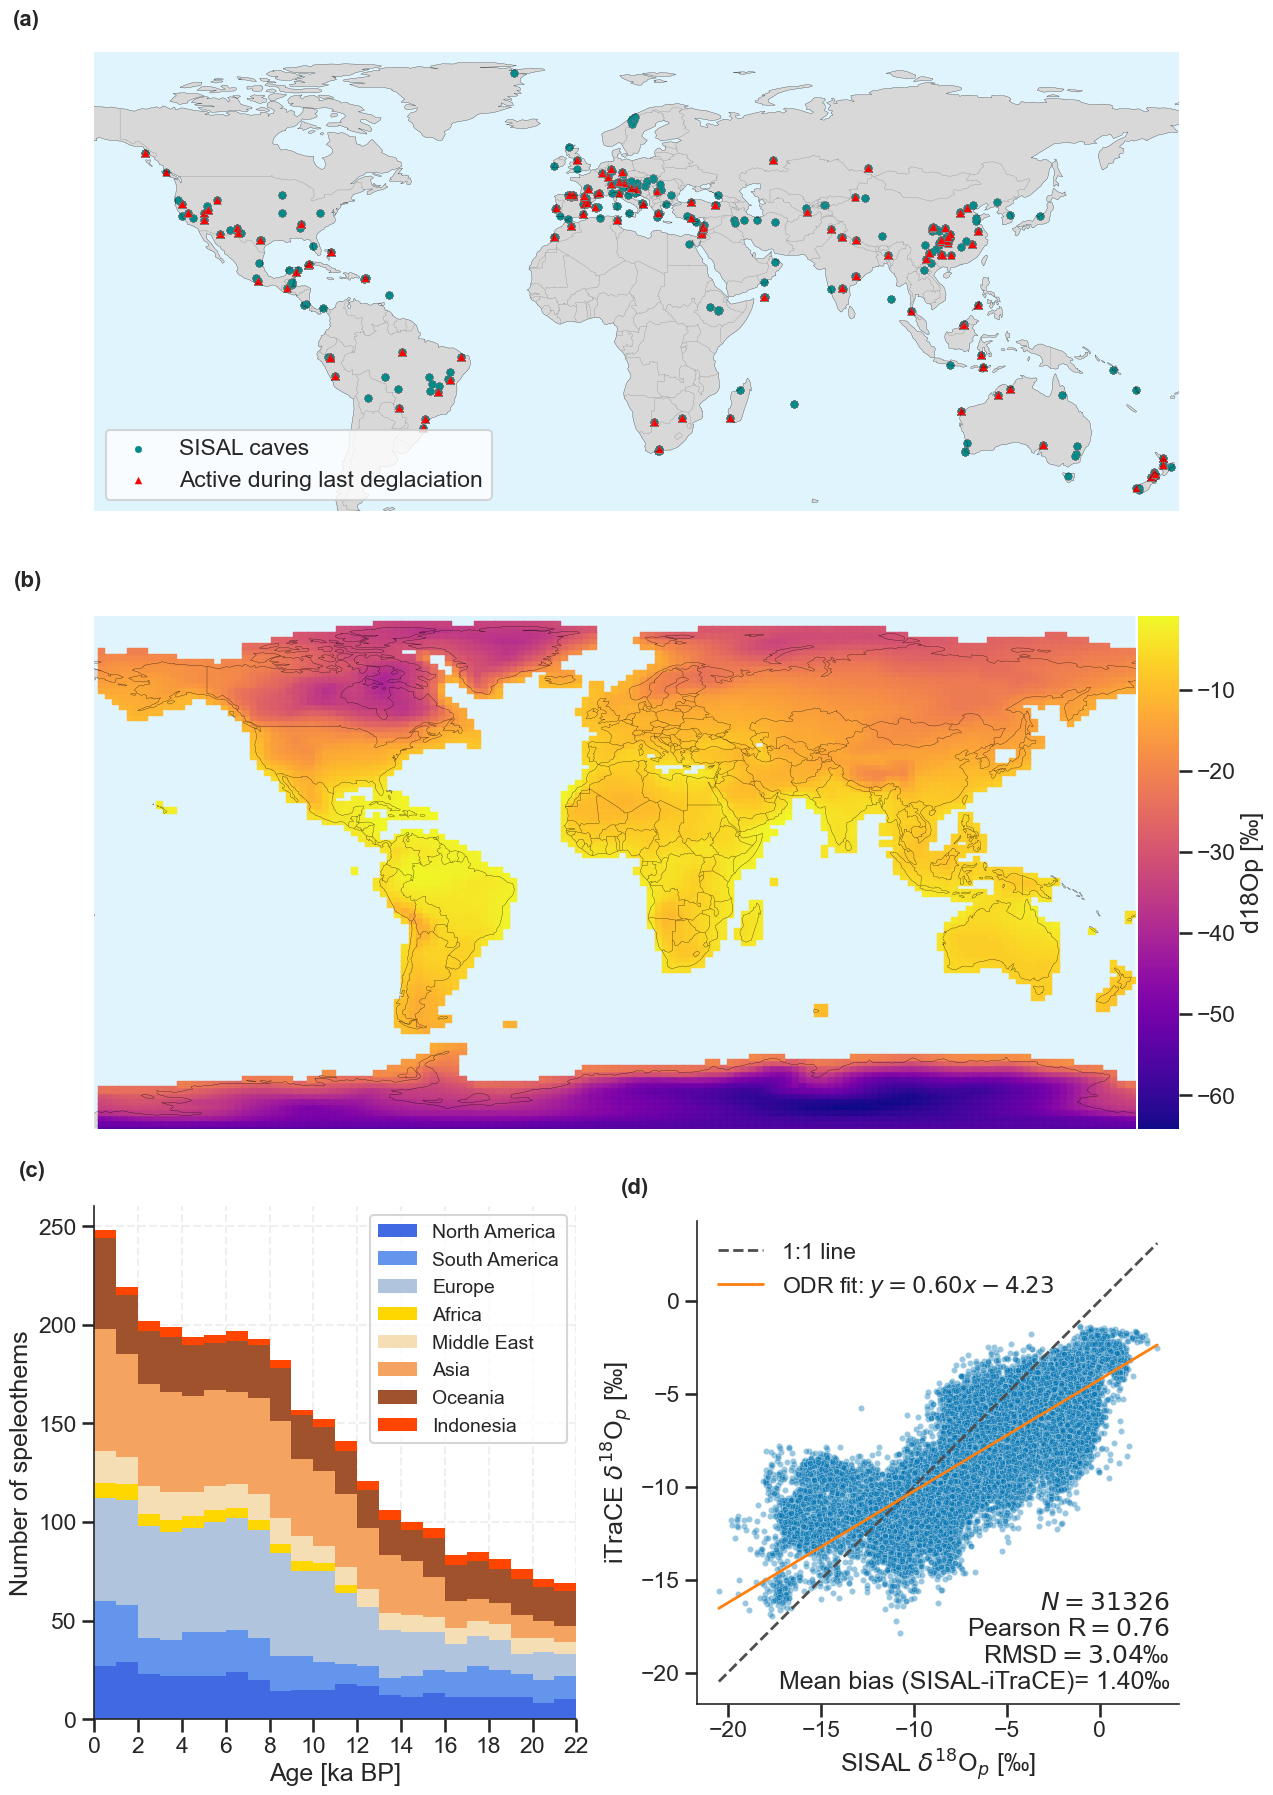

In [8]:
# Create figure with GridSpec: 3 rows, 2 columns
# (a) and (b) take full width on rows 0-1
# (c) and (d) split bottom row
fig = plt.figure(figsize=(14, 22))
gs = GridSpec(3, 2, figure=fig, hspace=0.15, wspace=0.25)

# Create axes
ax1 = fig.add_subplot(gs[0, :], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[1, :], projection=ccrs.PlateCarree())
ax3 = fig.add_subplot(gs[2, 0])
ax4 = fig.add_subplot(gs[2, 1])

# ======== SUBFIG (a) : sisal caves 
last_deglaciation_df = sisal_df[sisal_df.age.between(11000, 20000)]
other_df = sisal_df[(sisal_df.age < 11000) | (sisal_df.age > 20000)]

# Scatter plot of irregular points on first subplot
ax1.scatter(
    sisal_df.lon,
    sisal_df.lat,
    transform=ccrs.PlateCarree(),
    s=25,
    marker='o',
    color='darkcyan',
    edgecolors='grey',
    linewidths=0.1,
    label='SISAL caves'
)
ax1.scatter(
    last_deglaciation_df.lon,
    last_deglaciation_df.lat,
    transform=ccrs.PlateCarree(),
    s=28,
    marker='^',
    color='red',
    edgecolors='grey',
    linewidths=0.1,
    label='Active during last deglaciation'
)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.2)
ax1.add_feature(cfeature.LAND, facecolor="#d8d8d8", edgecolor="none")
ax1.add_feature(cfeature.OCEAN, facecolor="#dff4fd", edgecolor="none")
ax1.spines['geo'].set_visible(False)
country_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none')
ax1.add_feature(country_borders, edgecolor='gray', linewidth=0.2)
ax1.legend(loc='lower left')
ax1.text(-0.05, 1.05, '(a)', transform=ax1.transAxes, fontsize=16, fontweight='bold', va='bottom', ha='right')


# ====== SUBFIG (b) : itrace example

plot_utils.plot_isoscape_latlon_platecarree_df(
    itrace_df[itrace_df.time == 20000],
    title=None,
    cmap='plasma',
    countries_borders=True,
    s=28,
    ax=ax2,
    fig=fig
)
ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes, fontsize=16, fontweight='bold', va='bottom', ha='right')

# ======== SUBFIG (c) : distribution of the speleothem records among the continents
sisal_df_cont = sisal_utils.retrieve_continent_from_lat_lon(sisal_df,'lat','lon')
continents = sisal_df_cont.continent.unique()

bins = np.arange(0,500001,1000)
bin_centers = (bins[:-1] + bins[1:]) / 2
speleothems_in_bin = np.zeros(len(bin_centers))
speleothems_in_continent_bin = {}
for continent in continents :
    speleothems_in_continent_bin[continent] = np.zeros(len(bin_centers))
    continent_sites = sisal_df_cont.loc[sisal_df_cont['continent'] == continent,"site_id"].values
    continent_df    = sisal_df_cont[sisal_df_cont["site_id"].isin(continent_sites)]
    for i in range(len(bins)-1):
        bin_start = bins[i]
        bin_end = bins[i+1]
        speleothems_in_continent_bin[continent][i] = len(continent_df.loc[(continent_df['age'] >= bin_start) & (continent_df['age'] < bin_end),"entity_id"].unique())

colors = ['royalblue','cornflowerblue','lightsteelblue','gold','wheat','sandybrown','sienna','orangered']
for continent,color in zip(['North America','South America','Europe','Africa','Middle East','Asia','Oceania','Indonesia'],colors):
    if continent in speleothems_in_continent_bin.keys():
        ax3.bar(bin_centers, speleothems_in_continent_bin[continent], bottom=speleothems_in_bin, width=1000, label=continent, color=color,edgecolor='none',linewidth=0.5)
        speleothems_in_bin += speleothems_in_continent_bin[continent]

ax3.legend(fontsize=14)
ax3.set_xlabel('Age [ka BP]')
ax3.set_ylabel('Number of speleothems')
sns.despine(ax=ax3, top=True, right=True)
xticks = np.arange(0, 500001, 2000)            
ax3.set_xticks(xticks)
ax3.set_xticklabels(xticks // 1000)
ax3.set_xlim(0, 22000)
ax3.grid()
ax3.text(-0.1, 1.05, '(c)', transform=ax3.transAxes, fontsize=16, fontweight='bold', va='bottom', ha='right')

# ======== SUBFIG (d) : correlation scatter plot
paired_df = pd.read_csv('../output/data_exploration/correlationanalysis_paired_df_lininterp_2026_04_16.csv')
paired_df['itrace_d18Op']= np.array(paired_df.itrace_d18Op.values, dtype='float64')
x = 'sisal_d18Op'
y = 'itrace_d18Op'
# metrics
r, p_value = pearsonr(np.array(paired_df[x].values), np.array(paired_df[y].values))
rmse = utils.RMSE(paired_df[x].values, paired_df[y].values)
bias = np.mean(paired_df[x].values - paired_df[y].values)
sns.scatterplot(data=paired_df, x=x, y=y, s=20, alpha=0.4, ax=ax4)
# 1:1 line
min_val = min(paired_df[x].min(), paired_df[y].min())
max_val = max(paired_df[x].max(), paired_df[y].max())
ax4.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=2, color="0.3", label="1:1 line")

# Linear fit
def linear_model(B, x):
    return B[0]*x+B[1]

model = odr.Model(linear_model)
data = odr.Data(paired_df[x], paired_df[y])
odr_fit = odr.ODR(data, model, beta0=[1, 0])
out = odr_fit.run()
slope, intercept = out.beta
x_vals = np.linspace(min_val, max_val, 200)
y_vals = intercept + slope * x_vals
ax4.plot(x_vals, y_vals, linewidth=2, label=fr'ODR fit: $y={slope:.2f}x {intercept:+.2f}$', color='tab:orange')
ax4.text(0.98, 0.02,
    fr'$N = {len(paired_df)}$' '\n'
    fr'Pearson R$={r:.2f}$' '\n'
    fr'RMSD$={rmse:.2f}$‰' '\n'
    r'Mean bias (SISAL-iTraCE)=' f'{bias : .2f}‰',
    transform=ax4.transAxes, va='bottom', ha='right',
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.85", alpha=0.))
ax4.set_xlabel(r'SISAL $\delta^{18}$O$_p$ [‰]')
ax4.set_ylabel(r'iTraCE $\delta^{18}$O$_p$ [‰]')

# Final styling
sns.despine(ax=ax4)
ax4.legend(frameon=False)
ax4.set_aspect('equal', adjustable='box')
ax4.text(-0.1, 1.05, '(d)', transform=ax4.transAxes, fontsize=16, fontweight='bold', va='bottom', ha='right')

# plt.savefig('../output/data_exploration/essd_fig1.png', dpi=300, bbox_inches='tight')
plt.show()
